[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/k_brazos/softmax_normal_dist_experiment.ipynb)

# Estudio del bandido de k-brazos mediante el algoritmo Softmax con distribución normal

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo Softmax con brazos cuya recompensa viene dada por una función de distribución normal.

In [ ]:
!git clone https://github.com/ddumu/dourado-minguell-eml-mia-um-p1
%cd dourado-minguell-eml-mia-um-p1/k_brazos/
%ls

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/softmax_normal_dist"

## Librerías

In [ ]:
import sys
import random
import numpy as np

sys.path.append('./src')

from arms import ArmNormal, Bandit
from experiment import run_experiment
from algorithms import SoftMax
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertinente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento acumulado y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmNormal.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 8 con una recompensa media esperada de 9.56. Se van a comparar los resultados con distintos valores para la temperatura:
 - temperature = 0.01
 - temperature = 0.1
 - temperature = 1
 - temperature = 5

In [5]:
# Definir los algoritmos softmax con diferente epsilon
algorithms_softmax = [
    SoftMax(k=K, temperature=0.01),
    SoftMax(k=K, temperature=0.1),
    SoftMax(k=K, temperature=1),
    SoftMax(k=K, temperature=5)
]

# Ejecutar el experimento
rewards_softmax, optimal_selections_softmax, regret_accumulated_softmax, arm_stats_softmax = run_experiment(bandit, algorithms_softmax, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obtenidos mediante las correspondientes gráficas.

#### Recompensas promedio

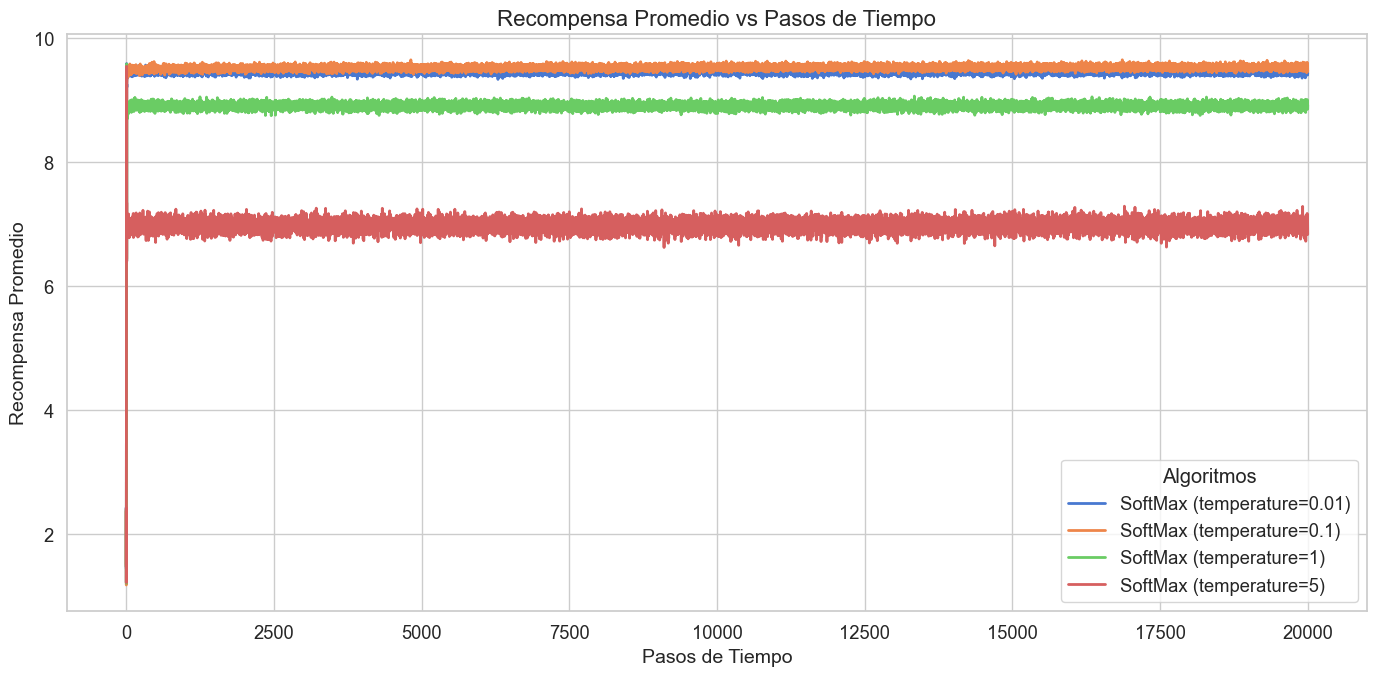

In [6]:
plot_average_rewards(STEPS, rewards_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

La recompensa promedio muestra como los valores de temperatura bajos obtienen mejores recompensas. Además, en todos los casos, se estabiliza rápido o no muestra tendencias de cambio a lo largo de los pasos.

#### Selecciones óptimas

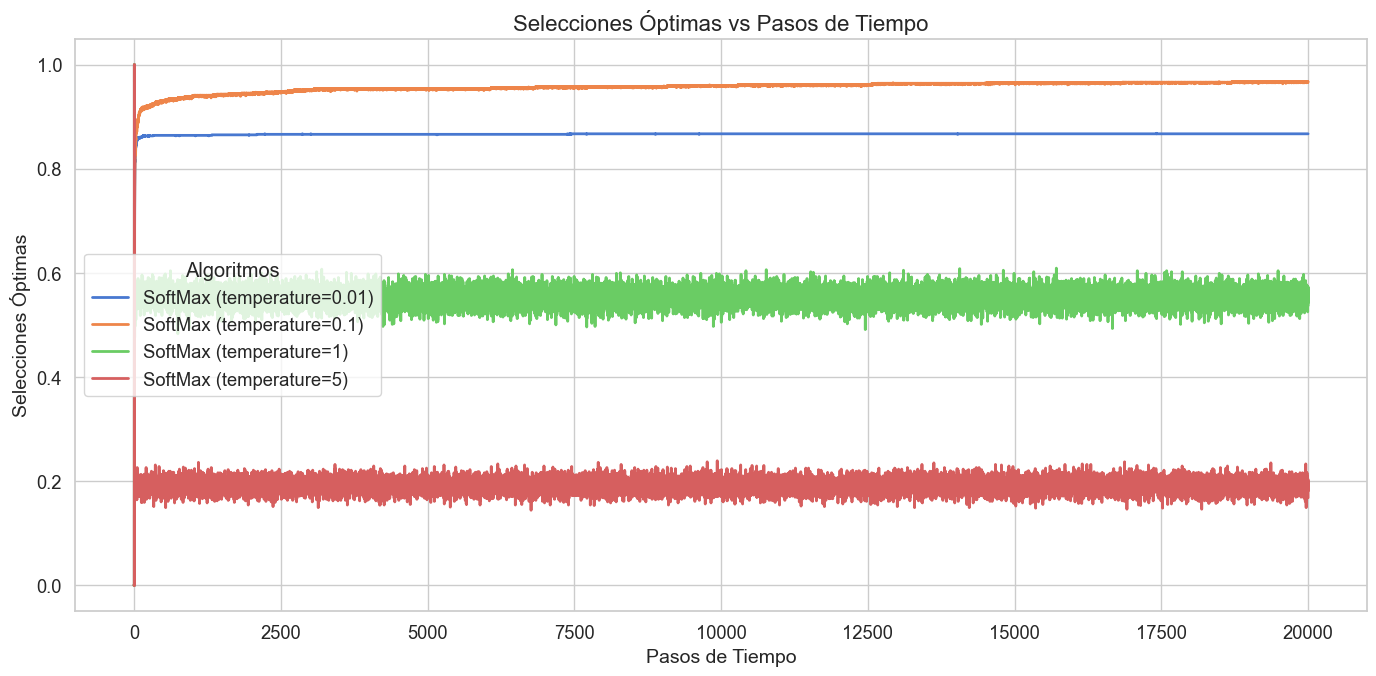

In [7]:
plot_optimal_selections(STEPS, optimal_selections_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

Se aprecia una gran diferencia en el porcentaje de selecciones óptimas. Temperatura 5 y 1 no consiguen superar el 60%, la temperatura 0.01 que ofrece menos exploración obtiene un porcentaje en torno al 90%, pero se estanca rápidamente. La configuración con temperatura 0.1 es la que mejor porcentaje consigue quedándose cerca del 100%.

#### Arrepentimiento

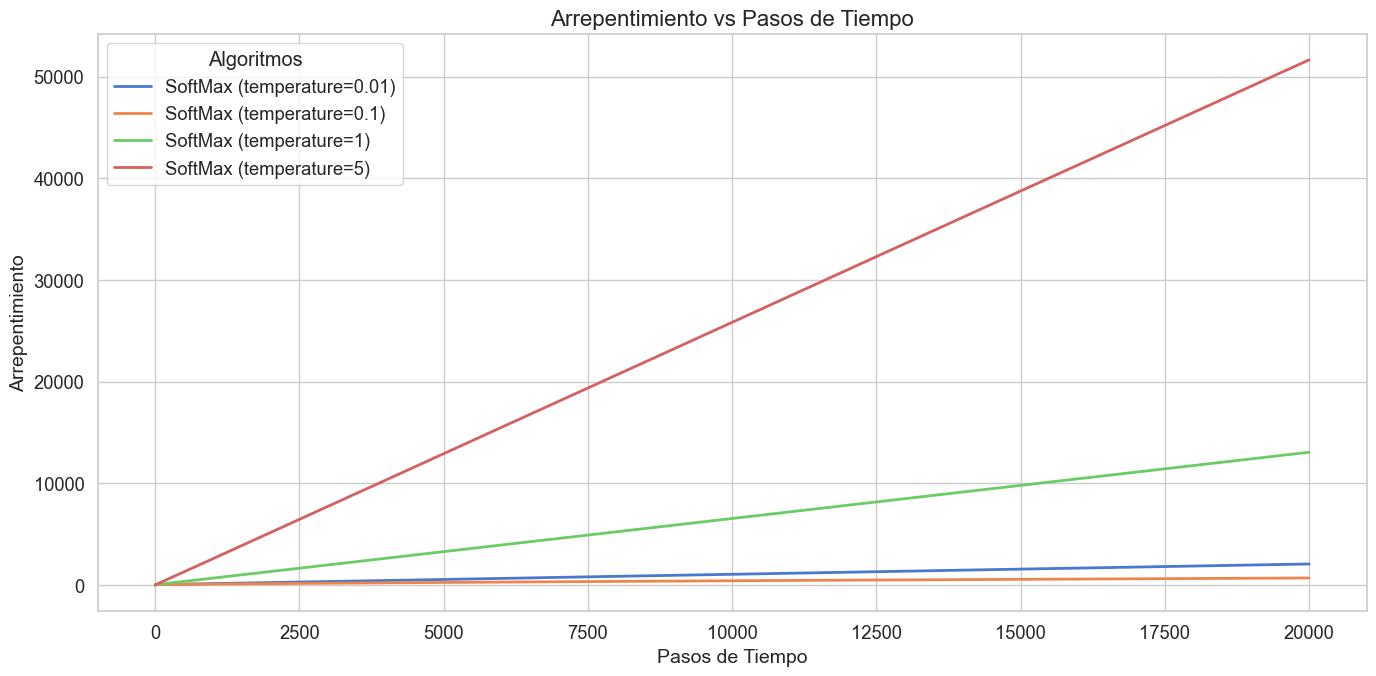

In [8]:
plot_regret(STEPS, regret_accumulated_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

El arrepentimiento acumulado se comporta de forma coherente al porcentaje de selecciones óptimas. El error acumulado de la temperatura 0.01 tiene una ligera tendencia alcista. Para la temperatura 0.1 no se ve ninguna tendencia demasiado pronunciada, lo que indica que parece tener la tasa de arrepentimiento controlada.

#### Estadísticas por brazo

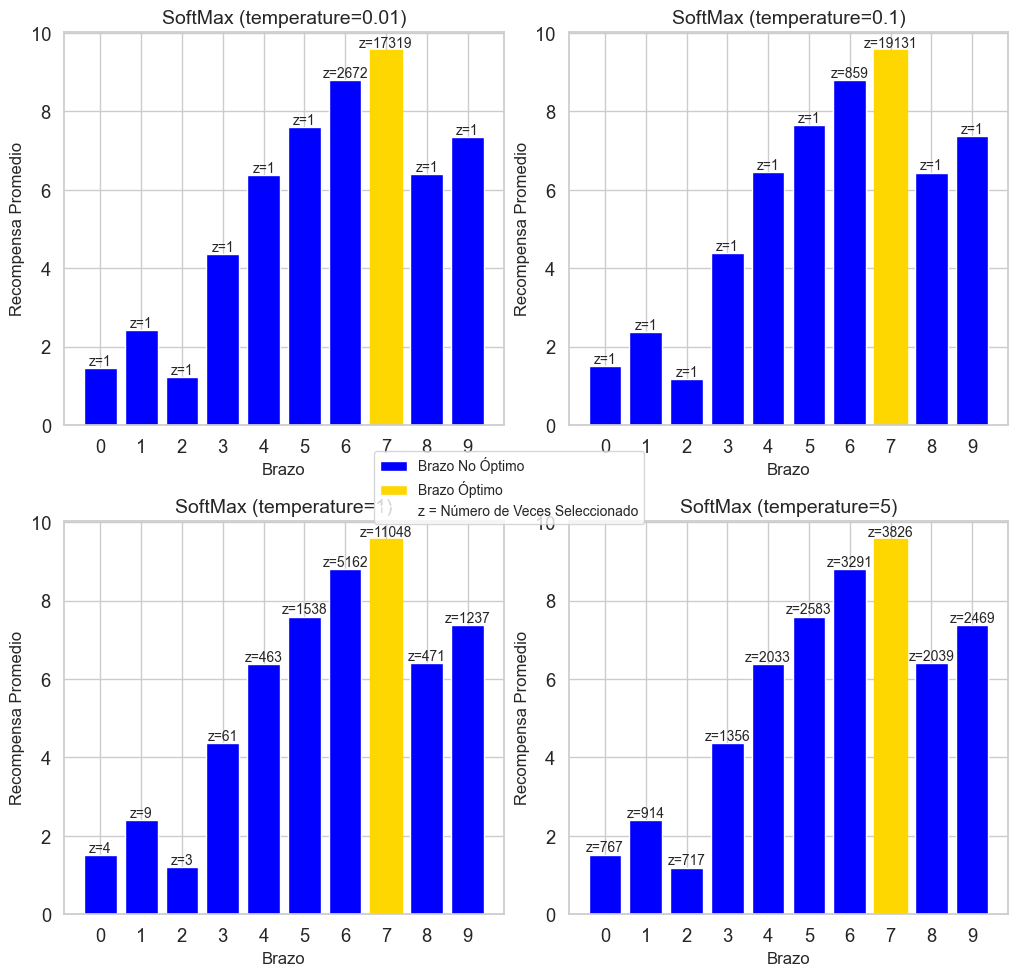

In [9]:
plot_arm_statistics(arm_stats_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

Las estadísticas desglosadas por brazo confirman que todas las versiones del algoritmo cumplen que eligen el mejor brazo en el mayor número de ocasiones, pero que una exploración pequeña como temperature=0.1 obtiene mejores resultados que una casi total explotación o una exploración excesiva.

## Conclusiones

Con el algoritmo Softmax, se puede ver como a lo largo de los pasos mejora sustancialmente el arrepentimiento por cada tirada gracias a su enfoque probabilístico. Con mayor probabilidad el mejor brazo será seleccionado, si no lo es, debido a su enfoque de ordenamiento según la recompensa promedio conseguida, otros brazos cercanos al óptimo serán los más probables a ser elegidos.